# AutoEIT — Transcription Quality: Canary-1B-v2 vs. Canary-1B and the rest (resegmented, hit recordings)

[NVIDIA Canary-1B-v2](https://huggingface.co/nvidia/canary-1b-v2) (`nvidia/canary-1b-v2`,
released 2026-06-23) is a follow-up checkpoint to `canary-1b` (see
`notebooks/model_comparison/analyze_canary_transcription_quality.ipynb`), the best-scoring system in this
comparison so far. Same FastConformer-Transformer encoder-decoder architecture, but expanded from
4 to 25 supported languages, and -- unlike v1 -- its decoder actually emits the timestamp tokens
NeMo needs, so it produces real per-word timestamps instead of v1's single-whole-clip-segment
fallback (see `src/transcription/transcribe_canary_v2.py`). Tried as a cheap follow-up: does a
newer checkpoint of the same architecture improve on canary-1b's already-best result, or was the
v1 win checkpoint-specific rather than purely architectural?

It was run via `src/transcription/transcribe_resegmented_canary_v2.py` over every recording in
`data/segmented/v2/` (hit and miss alike, same convention as canary-1b/whisper/parakeet/wav2vec2/
fastconformer -- unlike crisperwhisper/mms/seamlessm4t, which are hit-only), then merged with the
existing outputs and the human-rater transcriptions via
`src/postprocessing/build_postprocessed_csv_resegmented.py` (same rank-based item<->Sentence
alignment and WER/MER/CER scoring as the other resegmented-transcription-quality notebooks).

## Metrics: WER, MER, and CER

- **WER (Word Error Rate)** = (S + D + I) / N, where N is the number of words in the reference.
  Unbounded above 1.0 when there are many insertions relative to the reference.
- **MER (Match Error Rate)** = (S + D + I) / (S + D + C + I). Same edit counts as WER, but always in
  [0, 1] -- doesn't blow up the way WER can on insertion-heavy output.
- **CER (Character Error Rate)** -- the same idea as WER but over characters, more forgiving of
  near-miss spelling/inflection errors and less sensitive to tokenization.

All three are computed after lowercasing and stripping punctuation (see `normalize_text` in
`build_postprocessed_csv.py`), scored against both human raters, restricted to the 102 hit
recordings where the rank-based item<->Sentence alignment is trustworthy.

## Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
POSTPROCESSED_ROOT = Path("../../data/postprocessed/resegmented")
VERSIONS = ["version_a", "version_b"]
ASR_SOURCES = ["whisper", "parakeet", "wav2vec2", "crisperwhisper", "fastconformer", "canary", "mms", "seamlessm4t", "canary_v2"]
RATERS = ["rater1", "rater2"]
METRICS = ["wer", "mer", "cer"]

hit_recordings = set(Path("../../data/resegmented_hit_recordings.txt").read_text(encoding="utf-8").split())
print(f"{len(hit_recordings)} hit recordings")

102 hit recordings


## Load per-item scores

One tidy row per (recording, sentence, ASR source, rater), across all hit recordings.

In [3]:
def load_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            for source in ASR_SOURCES:
                for rater in RATERS:
                    cols = [f"{source}_{m}_{rater}" for m in METRICS]
                    if cols[0] not in df.columns:
                        continue
                    sub = df[["sentence_number", *cols]].dropna()
                    for _, row in sub.iterrows():
                        records.append({
                            "version": version,
                            "recording": recording_dir.name,
                            "sentence_number": row["sentence_number"],
                            "source": source,
                            "rater": rater,
                            "wer": row[cols[0]],
                            "mer": row[cols[1]],
                            "cer": row[cols[2]],
                        })
    return pd.DataFrame(records)


scores = load_scores(hit_recordings)
n_rec = scores["recording"].nunique()
print(f"{len(scores)} scored items, {n_rec} recordings")

52911 scored items, 98 recordings


## Human floor

For context, the inter-rater agreement floor (rater1 vs. rater2, same scoring, see `analyze_interrater_agreement.ipynb` for the full writeup) over this same 102-recording set, shown alongside the ASR systems below.

In [4]:
def load_human_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            if "human_wer" not in df.columns:
                continue
            sub = df[["sentence_number", "human_wer", "human_mer", "human_cer"]].dropna()
            for _, row in sub.iterrows():
                records.append({
                    "version": version,
                    "recording": recording_dir.name,
                    "sentence_number": row["sentence_number"],
                    "source": "human",
                    "rater": "rater1_vs_rater2",
                    "wer": row["human_wer"],
                    "mer": row["human_mer"],
                    "cer": row["human_cer"],
                })
    return pd.DataFrame(records)


human_scores = load_human_scores(hit_recordings)
scores_with_human = pd.concat([scores, human_scores], ignore_index=True)
print(f"human floor: {len(human_scores)} scored sentences")

human floor: 2940 scored sentences


In [5]:
source_colors = {
    "whisper": "#4C72B0",
    "parakeet": "#DD8452",
    "wav2vec2": "#55A868",
    "crisperwhisper": "#C44E52",
    "fastconformer": "#8172B2",
    "canary": "#937860",
    "mms": "#64B5CD",
    "seamlessm4t": "#CCB974",
    "canary_v2": "#4C4C4C",
    "human": "#777777",
}
DISPLAY_SOURCES = ASR_SOURCES + ["human"]


def summarize(scores: pd.DataFrame, order: list[str] = ASR_SOURCES) -> pd.DataFrame:
    mean_tbl = scores.groupby("source")[METRICS].mean().round(4).reindex(order)
    median_tbl = scores.groupby("source")[METRICS].median().round(4).reindex(order)
    pct_perfect = scores.groupby("source")["wer"].apply(lambda x: (x == 0).mean()).round(3).reindex(order)
    out = mean_tbl.add_suffix("_mean").join(median_tbl.add_suffix("_median"))
    out["wer_pct_perfect"] = pct_perfect
    return out


def plot_metrics(scores: pd.DataFrame, title: str, save_path: str, order: list[str] = ASR_SOURCES) -> None:
    summary = scores.groupby("source")[METRICS].mean().reindex(order)
    x = np.arange(len(order))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, metric in enumerate(METRICS):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, summary[metric], width, label=metric.upper())
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("Mean error rate")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

## All 9 ASR systems vs. human floor (n=102 hit recordings, both raters)

In [6]:
summarize(scores_with_human, order=DISPLAY_SOURCES)

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
parakeet,0.2805,0.2596,0.1558,0.1429,0.1429,0.0513,0.329
wav2vec2,0.3230,0.3003,0.1489,0.2500,0.2500,0.0769,0.207
crisperwhisper,0.6897,0.6380,0.3761,0.7500,0.7059,0.2857,0.020
fastconformer,0.2506,0.2331,0.1319,0.1667,0.1667,0.0606,0.297
canary,0.2476,0.2129,0.1341,0.1429,0.1250,0.0435,0.368
mms,0.3987,0.3815,0.1893,0.2857,0.2857,0.1000,0.205
seamlessm4t,0.3770,0.3186,0.2186,0.2222,0.2000,0.0930,0.270
canary_v2,0.3014,0.2593,0.1809,0.1667,0.1667,0.0638,0.327


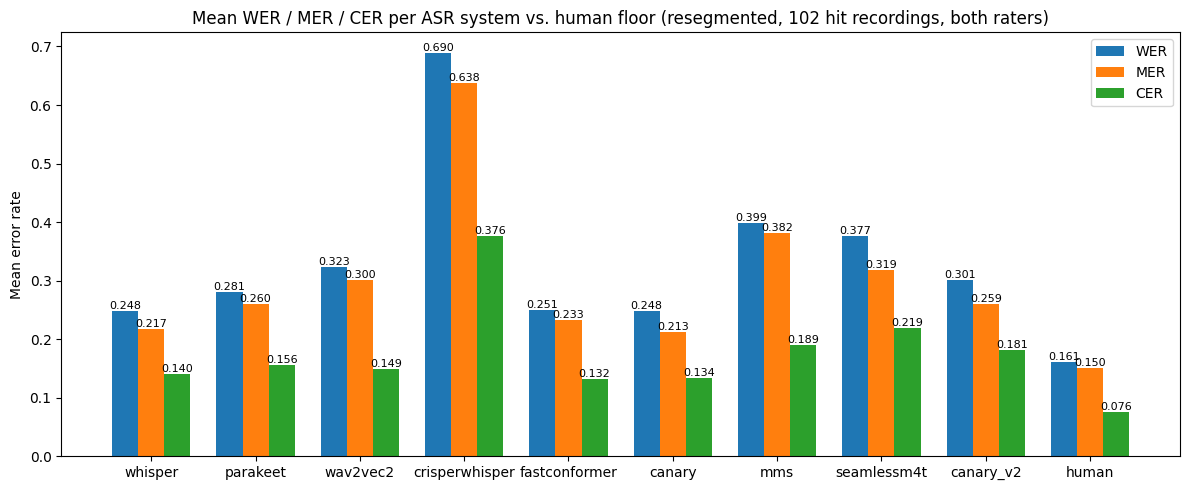

In [7]:
plot_metrics(
    scores_with_human,
    "Mean WER / MER / CER per ASR system vs. human floor (resegmented, 102 hit recordings, both raters)",
    "../plots/canary_v2_transcription_quality_metrics.png",
    order=DISPLAY_SOURCES,
)

## Canary-1B-v2 vs. Canary-1B (the core question)

Does the newer, 25-language checkpoint improve on v1's already-best-in-class result, or does it
trade accuracy for broader language coverage -- the same pattern seen with MMS vs. wav2vec2 (see
`notebooks/model_comparison/analyze_mms_transcription_quality.ipynb`)?

In [8]:
summarize(scores, order=["canary", "canary_v2"])

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
canary,0.2476,0.2129,0.1341,0.1429,0.1250,0.0435,0.368
canary_v2,0.3014,0.2593,0.1809,0.1667,0.1667,0.0638,0.327


## Per-item head-to-head

Of the items where v1 and v2 disagree on WER, which one wins more often?

In [9]:
pair = (
    scores[scores["source"].isin(["canary", "canary_v2"])]
    .pivot_table(index=["recording", "sentence_number", "rater"], columns="source", values="wer")
    .dropna()
)
n_v2_better = (pair["canary_v2"] < pair["canary"]).sum()
n_v1_better = (pair["canary_v2"] > pair["canary"]).sum()
n_tied = (pair["canary_v2"] == pair["canary"]).sum()
print(f"v2 better: {n_v2_better}, v1 better: {n_v1_better}, tied: {n_tied}")

v2 better: 766, v1 better: 1672, tied: 3441


## Output richness: does v2's timestamp fix show up in the summary stats?

v1's decoder never emitted timestamp tokens, so every v1 item fell back to a single whole-clip
segment with `words: []` -- meaning `word_count` is always 0 and `mean_word_prob` is always null
for `canary` in every CSV. v2 fixes the timestamp emission, so it should show non-zero word counts
(still no per-word confidence, same as parakeet/canary v1).

In [10]:
rows = []
for version in VERSIONS:
    for recording_dir in sorted((POSTPROCESSED_ROOT / version).iterdir()):
        if recording_dir.name not in hit_recordings:
            continue
        rows.append(pd.read_csv(recording_dir / "transcriptions.csv"))
all_rows = pd.concat(rows, ignore_index=True)

print("canary (v1) word_count mean:", all_rows["canary_word_count"].mean())
print("canary_v2 word_count mean:", all_rows["canary_v2_word_count"].mean())
print("canary_v2 mean_word_prob non-null:", all_rows["canary_v2_mean_word_prob"].notna().sum(), "/", len(all_rows))

canary (v1) word_count mean: 0.0
canary_v2 word_count mean: 7.420915032679739
canary_v2 mean_word_prob non-null: 0 / 3060


## Takeaways

- **Canary-1B-v2 is clearly worse than v1 on every metric**: mean WER 0.301 vs. 0.248, MER 0.259
  vs. 0.213, CER 0.181 vs. 0.134, word-perfect rate 32.7% vs. 36.8%. The newer checkpoint drops
  from the best system overall (1st of 8) to the middle of the pack (5th of 9), behind whisper,
  fastconformer, and parakeet, and just ahead of wav2vec2.
- Per-item, v1 wins more often than v2 wins on the items where they disagree (1,672 vs. 766, out of
  3,441 exact ties) -- not a case of a few outlier clips dragging the mean down, v1 is more often
  the better transcription.
- This mirrors the MMS-vs-wav2vec2 result from earlier in this comparison: broadening language
  coverage (4 -> 25 languages) appears to dilute per-language capacity on this narrow, L2-accented,
  short-sentence Spanish task, the same way MMS's ~1,100-language adapter training underperformed
  wav2vec2's dedicated Spanish fine-tune.
- v2's one genuine improvement is output richness, not accuracy: it fixes v1's missing
  word-level timestamps (v1's `word_count` is always 0 due to the fallback whole-clip segment; v2
  averages ~7.4 words/item with real timestamps), which matters if downstream tooling needs
  word-level alignment -- but it doesn't come with a confidence score, and it doesn't offset the
  accuracy regression.
- Net result: **no pipeline change recommended**, and specifically do **not** swap `canary-1b` for
  `canary-1b-v2` for this dataset -- v1 remains the strongest system tried so far. v2 would only be
  worth revisiting if word-level timestamps become a hard requirement and the accuracy trade-off is
  judged acceptable.